# JaxQSOFit Tutorial: SDSS Example + Broad-Line Measurements

This notebook demonstrates the main features of `jaxqsofit` using a real SDSS spectrum near:

```python
coord = SkyCoord(184.0307, -2.2383, unit='deg')
```

Recommended fitting mode: `config.inference.method = 'optax+nuts'`.
This runs the staged SVI/Optax MAP initializer, then performs full posterior sampling with NUTS.

It covers:
- Fetching spectrum with `astroquery`
- Running fits (`nuts`, `optax`, `optax+nuts`)
- Overriding priors with `PriorConfig`
- Measuring broad-line FWHM and luminosity from fitted components

Set `config.inference.method = "optax"` for staged SVI/Optax MAP optimization (continuum warm start, then full model). Set `config.inference.method = "optax+nuts"` to use that staged MAP point to initialize NUTS.


In [1]:
import jaxqsofit
import jaxqsofit.defaults as defaults
import numpy as np

/Users/colinburke/miniforge3/envs/jaxcpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import numpyro.distributions as dist

from astroquery.sdss import SDSS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.cosmology import FlatLambdaCDM

from jaxqsofit import (
    ContinuumConfig,
    HostConfig,
    InferenceConfig,
    JAXQSOFit,
    LineConfig,
    Observation,
    OutputConfig,
    PreprocessingConfig,
    PriorConfig,
    FitConfig,
    SpectroscopyData,
)



## 1. Download one SDSS spectrum


In [3]:
# The spectrum is downloaded in the next cell.

In [4]:
coord = SkyCoord(184.0307, -2.2383, unit='deg')
# z0.706_230847.66-002028.4
#coord = SkyCoord.from_name('NGC 5548')
xid = SDSS.query_region(coord, spectro=True, radius=5 * u.arcsec)
sp = SDSS.get_spectra(matches=xid[:1])[0]

tb = sp[1].data
lam = np.asarray(10 ** tb['loglam'], dtype=float)
flux = np.asarray(tb['flux'], dtype=float)
ivar = np.asarray(tb['ivar'], dtype=float)
wdisp = np.asarray(tb['wdisp'], dtype=float) if 'wdisp' in tb.names else None

err = np.full_like(flux, 1e-6)
m = np.isfinite(ivar) & (ivar > 0)
err[m] = 1.0 / np.sqrt(ivar[m])

z = float(sp[2].data['z'][0])
ra = float(coord.ra.deg)
dec = float(coord.dec.deg)

print(f'Nspec pixels: {lam.size}')
print(f'z = {z:.5f}')
if wdisp is not None and np.any(np.isfinite(wdisp) & (wdisp > 0)):
    dloglam = float(np.nanmedian(np.diff(np.log10(lam))))
    fwhm_pixels = 2.355 * wdisp[np.isfinite(wdisp) & (wdisp > 0)]
    sdss_resolving_power = float(np.nanmedian(1.0 / (np.log(10.0) * dloglam * fwhm_pixels)))
else:
    sdss_resolving_power = 2000.0
print(f'SDSS resolving power estimate R = {sdss_resolving_power:.0f}')

plate = int(sp[0].header.get('plateid', 0))
mjd = int(sp[0].header.get('mjd', 0))
fiber = int(sp[0].header.get('fiberid', 0))
sdss_filename = f"{plate:04d}-{mjd}-{fiber:04d}"


Nspec pixels: 3810
z = 0.10061
SDSS resolving power estimate R = 2152


In [5]:
sp.info()
print(sp[0].header)
print(sp[1].data.names)

Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     139   ()      
  1  COADD         1 BinTableHDU     26   3810R x 8C   ['E', 'E', 'E', 'J', 'J', 'E', 'E', 'E']   
  2  SPECOBJ       1 BinTableHDU    262   1R x 126C   ['6A', '4A', '16A', '23A', '16A', '8A', 'E', 'E', 'E', 'J', 'E', 'E', 'J', 'B', 'B', 'B', 'B', 'B', 'B', 'J', '22A', '19A', '19A', '22A', '19A', 'I', '3A', '3A', '1A', 'J', 'D', 'D', 'D', 'E', 'E', '19A', '8A', 'J', 'J', 'J', 'J', 'K', 'K', 'J', 'J', 'J', 'J', 'J', 'J', 'K', 'K', 'K', 'K', 'I', 'J', 'J', 'J', 'J', '5J', 'D', 'D', '6A', '21A', 'E', 'E', 'E', 'J', 'E', '24A', '10J', 'J', '10E', 'E', 'E', 'E', 'E', 'E', 'E', 'J', 'E', 'E', 'E', 'J', 'E', '5E', 'E', '10E', '10E', '10E', '5E', '5E', '5E', '5E', '5E', 'J', 'J', 'E', 'E', 'E', 'E', 'E', 'E', '25A', '21A', '10A', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'J', 'E', 'E', 'J', '1A', '1A', 'E', 'E', 'J', 'J', '1A', '5E', '5

## 2. Build a default prior config (auto-scaled from flux)

Use `HOST_SPS_MODEL` to switch between the two host-galaxy SPS modes:

- `"delayed"`: physical delayed-SFH host model with stellar mass, age, tau, and metallicity priors.
- `"mixture"`: free mixture/template-weight SPS model over the configured SSP grid, with an older-template prior on the mixture logits.



In [6]:
HOST_SPS_MODEL = "delayed"  # "delayed" or "mixture"

prior_config = PriorConfig.from_spectrum(
    flux=flux,
    redshift=z,
)

# Example override: slightly tighter PL slope and Fe normalization priors
prior_config.powerlaw.slope = dist.TruncatedNormal(loc=-1.5, scale=0.3, low=-3.5, high=0.5)
prior_config.fe.uv_norm = dist.LogNormal(np.log(max(1e-3 * np.median(np.abs(flux)), 1e-10)), 0.04)
prior_config.fe.op_over_uv = dist.Normal(0.0, 0.4)

# Robust line scale multipliers (optional)
prior_config.lines.dmu_scale_mult = 0.25
prior_config.lines.sig_scale_mult = 0.25
prior_config.lines.amp_scale_mult = 0.20

host_model = HOST_SPS_MODEL.lower()
if host_model == "delayed":
    # Physical delayed-SFH host path. These priors prefer an older, more
    # massive, near-solar stellar population for this low-z SDSS example.
    host_sfh_model = "delayed"
    host_age_grid_gyr = (0.3, 1.0, 3.0, 6.0, 10.0)
    host_logzsol_grid = (-0.5, 0.0, 0.2)

    prior_config.host.sfh_model = host_sfh_model
    prior_config.host.stellar_mass = dist.TruncatedNormal(loc=10.6, scale=0.4, low=9.5, high=12.0)
    prior_config.host.sfh_age_gyr = dist.Normal(np.log(7.0), 0.3)
    prior_config.host.sfh_tau_over_age = dist.Normal(np.log(0.25), 0.3)
    prior_config.host.metallicity = dist.Normal(0.0, 0.2)
    prior_config.host.metallicity_scatter = dist.Normal(np.log(0.1), 0.3)
    prior_config.host.aperture_scale = dist.Normal(0.0, 0.25)
elif host_model in {"mixture", "flexible"}:
    # Free mixture/template-weight SPS path. The age prior shifts the raw
    # template-weight logits toward older SSPs while keeping the mixture flexible.
    host_sfh_model = "flexible"
    host_age_grid_gyr = (0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0)
    host_logzsol_grid = (-1.0, -0.5, 0.0, 0.2)

    prior_config.host.sfh_model = host_sfh_model
    prior_config.host.aperture_scale = dist.Normal(0.0, 0.5)
    prior_config.host.template_age_prior = {
        "type": "prefer_old",
        "pivot_gyr": 1.0,
        "strength": 1.5,
        "min_logit": -3.0,
        "max_logit": 2.0,
    }
else:
    raise ValueError("HOST_SPS_MODEL must be 'delayed' or 'mixture'.")



## 3. Run a fit

Recommended:
- `config.inference.method = 'optax+nuts'` (staged SVI/Optax initialization, then full NUTS posterior)

Other options:
- `config.inference.method = 'nuts'` (full posterior, slower initialization)
- `config.inference.method = 'optax'` (staged MAP only, fastest, no posterior samples)


100%|██████████| 666/666 [00:05<00:00, 114.59it/s, init loss: 14014.2358, avg. loss [628-660]: 4388.8498]


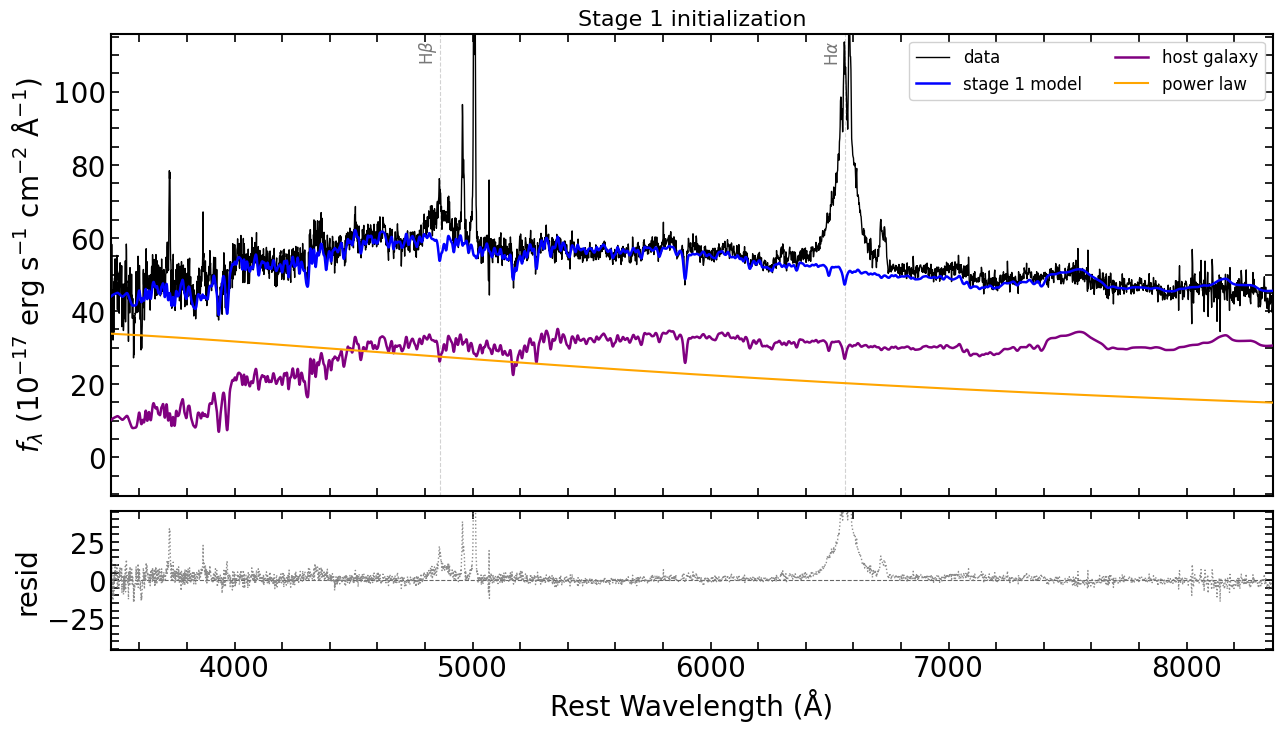

100%|██████████| 1334/1334 [00:16<00:00, 78.87it/s, init loss: 5211.1321, avg. loss [1255-1320]: 4307.8420] 


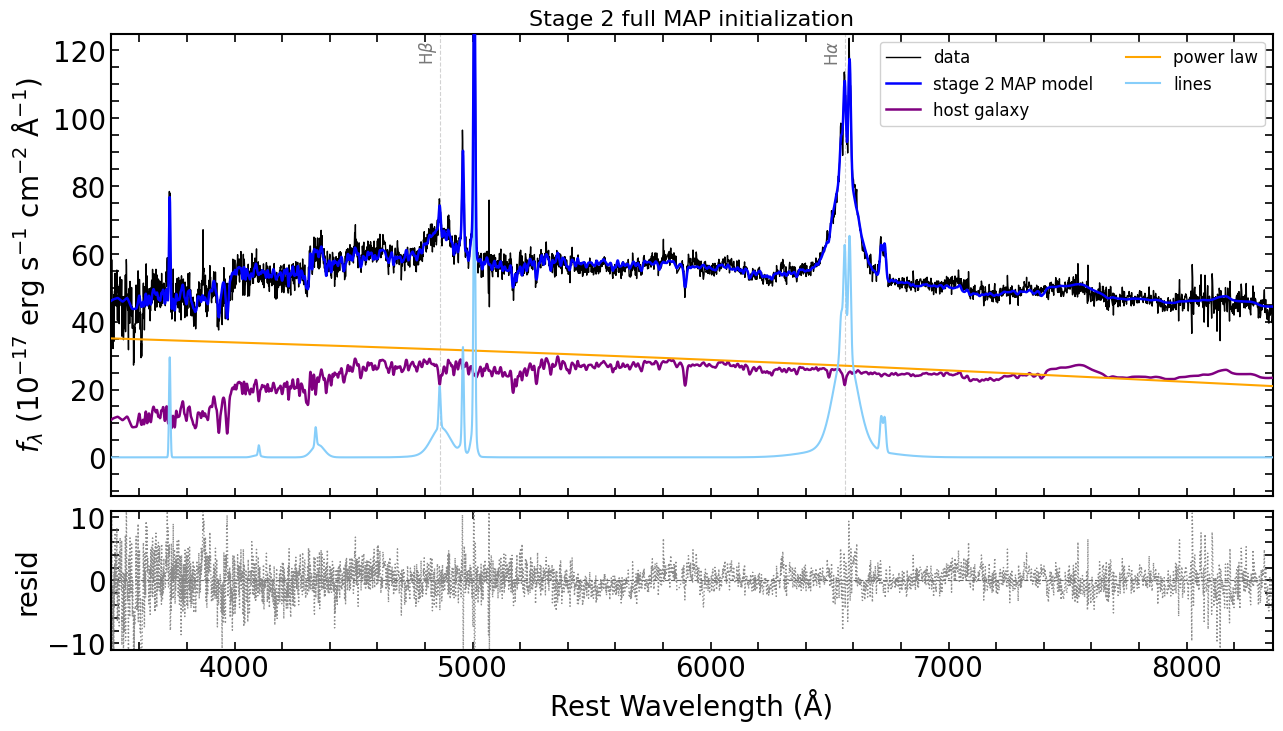

max data        : 159.85346122995483
max total model : 148.496898102709
max PL          : 35.082540925024446
max host        : 29.757099136829563
max FeII UV     : 0.002152227602518407
max FeII opt    : 0.01125486608490731
max Balmer cont : 0.0038829950453933013
max lines       : 92.64420497687634


warmup:  13%|█▎        | 20/150 [01:38<03:54,  1.80s/it, 255 steps of size 5.36e-04. acc. prob=0.80] 

In [ ]:
cfg = FitConfig(
    observation=Observation(
        object_id=sdss_filename,
        redshift=z,
        ra=ra,
        dec=dec,
        apply_mw_deredden=True,
    ),
    spectroscopy=SpectroscopyData(
        wave_obs=lam,
        fluxes=flux,
        errors=err,
        resolving_power=sdss_resolving_power,
    ),
    continuum=ContinuumConfig(
        fit_power_law=True,
        fit_feii=True,
        fit_balmer_continuum=True,
        fit_polynomial_tilt=True,
    ),
    host=HostConfig(
        enabled=True,
        sfh_model=host_sfh_model,
        dsps_ssp_fn='../tempdata.h5',
        age_grid_gyr=host_age_grid_gyr,
        logzsol_grid=host_logzsol_grid,
    ),
    lines=LineConfig(
        enabled=True,
        include_elg_narrow_lines=False,
        include_high_ionization_lines=False,
    ),
    inference=InferenceConfig(
        method='optax+nuts',
        map_steps=2000,
        learning_rate=1e-2,
        num_warmup=250,
        num_samples=100,
        num_chains=1,
        dense_mass=False,
        line_block_dense_mass=True,
        standardize_active_priors=True,
        target_accept_prob=0.82,
    ),
    output=OutputConfig(output_path='.', save_result=False, plot_fig=True, save_fig=False),
    prior_config=prior_config,
)

cfg.output.plot_init = True

q = JAXQSOFit(cfg)
result = q.fit()
q.nuts_diagnostics


In [ ]:
[k for k in q.numpyro_samples if "decentered" in k or k.endswith("_std")][:20]

['Balmer_Tau_std',
 'Balmer_norm_std',
 'Fe_FWHM_std',
 'Fe_shift_std',
 'Fe_uv_norm_std',
 'PL_apparent_log_norm_std',
 'PL_apparent_slope_std',
 'frac_jitter_std',
 'gal_v_kms_std',
 'line_OIII_wing_log_fwhm_std',
 'line_amp_Ha_std',
 'line_amp_Hb_std',
 'line_amp_Hd_std',
 'line_amp_Hg_std',
 'line_amp_OII_std',
 'line_broad_center_0_std',
 'line_broad_center_1_std',
 'line_broad_relative_offsets_0_std',
 'line_broad_relative_offsets_1_std',
 'line_dmu_independent_group_std']

In [ ]:
for k in ["PL_norm", "cont_norm", "log_frac_host", "frac_host",
          "log_stellar_mass", "log_host_aperture_scale", "host_aperture_scale"]:
    if hasattr(q, "init_stage1_samples") and k in q.init_stage1_samples:
        
        print(k, np.asarray(q.init_stage1_samples[k]).ravel())

log_stellar_mass [10.64866029]


In [ ]:
print(q.numpyro_samples.keys())
print(q.config.host.sfh_model)
print(q._fit_decompose_host)

dict_keys(['Balmer_Tau', 'Balmer_Tau_std', 'Balmer_norm', 'Balmer_norm_std', 'Balmer_vel', 'Fe_FWHM', 'Fe_FWHM_std', 'Fe_op_FWHM', 'Fe_op_shift', 'Fe_shift', 'Fe_shift_std', 'Fe_uv_FWHM', 'Fe_uv_norm', 'Fe_uv_norm_std', 'Fe_uv_shift', 'PL_apparent_log_norm_std', 'PL_apparent_slope_std', 'PL_norm', 'PL_slope', 'add_jitter', 'ebv', 'formed_stellar_mass', 'frac_fe_jitter', 'frac_jitter', 'frac_jitter_std', 'gal_lgmet', 'gal_lgmet_scatter', 'gal_sigma_kms', 'gal_v_kms', 'gal_v_kms_std', 'line_OIII_wing_log_fwhm', 'line_OIII_wing_log_fwhm_std', 'line_amp_Ha_std', 'line_amp_Hb_std', 'line_amp_Hd_std', 'line_amp_Hg_std', 'line_amp_OII_std', 'line_amp_group', 'line_broad_center_0_std', 'line_broad_center_1_std', 'line_broad_center_value_0', 'line_broad_center_value_1', 'line_broad_relative_offsets_0', 'line_broad_relative_offsets_0_std', 'line_broad_relative_offsets_1', 'line_broad_relative_offsets_1_std', 'line_dmu_group', 'line_dmu_independent_group', 'line_dmu_independent_group_std', 'line_

In [ ]:
import numpy as np

if "log_stellar_mass" in q.numpyro_samples:
    logm = np.asarray(q.numpyro_samples["log_stellar_mass"])
    print("log_stellar_mass", np.nanmedian(logm), np.nanpercentile(logm, [16, 84]))
elif "fsps_weights_raw" in q.numpyro_samples:
    weights = np.asarray(q.pred_out.get("fsps_weights", []))
    if weights.size:
        median_weights = np.nanmedian(weights, axis=0)
        print("mixture SPS fsps_weights median", median_weights)
    else:
        print("mixture SPS fit: no physical log_stellar_mass site is sampled")
else:
    print("No host mass or mixture-weight samples found.")



log_stellar_mass 10.475632447367435 [10.42354029 10.51988406]


Estimate reduced Chi squared:

In [ ]:
resid = np.asarray(q.flux) - np.asarray(q.model_total)
sigma = np.asarray(q.err)

# include fitted jitter (recommended)
if q.numpyro_samples is not None:
    s = q.numpyro_samples
    frac_j = float(np.median(np.asarray(s.get("frac_jitter", 0.0))))
    add_j  = float(np.median(np.asarray(s.get("add_jitter", 0.0))))
    sigma = np.sqrt(sigma**2 + (frac_j*np.abs(np.asarray(q.model_total)))**2 + add_j**2)

m = np.isfinite(resid) & np.isfinite(sigma) & (sigma > 0)
z = resid[m] / sigma[m]

chi2 = float(np.sum(z**2))
chi2_per_pixel = float(np.mean(z**2))      # more stable than reduced chi2 here
wrms = float(np.sqrt(np.mean(z**2)))

print("chi2:", chi2)
print("chi2_per_pixel:", chi2_per_pixel)
print("wrms (normalized residual std):", wrms)


chi2: 4679.060001350903
chi2_per_pixel: 1.2280997378873761
wrms (normalized residual std): 1.1081966151759246


## 4. MCMC diagnostics (trace + corner)


In [ ]:
q.plot_mcmc_diagnostics?

Signature:
q.plot_mcmc_diagnostics(
    do_trace=True,
    do_corner=True,
    param_names=None,
    max_vector_elems=2,
    corner_bins=30,
    corner_max_points=2000,
    save_fig_path=None,
    show_plot=False,
)
Docstring:
Plot trace and/or corner diagnostics in a single convenience call.

Parameters
----------
do_trace : bool, optional
    If True, render the trace plot.
do_corner : bool, optional
    If True, render the corner plot.
param_names : list[str] | str | None, optional
    Parameter selector shared by both plots. Use ``'all'`` to include
    all posterior keys.
max_vector_elems : int or None, optional
    Maximum number of vector elements to expand per key.
corner_bins : int, optional
    Histogram bin count for the corner plot.
corner_max_points : int, optional
    Maximum posterior draws to use in the corner plot.
save_fig_path : str or None, optional
    Output directory when saving figures. If ``None``, uses
    ``self.output_path`` or the current directory.
show_pl

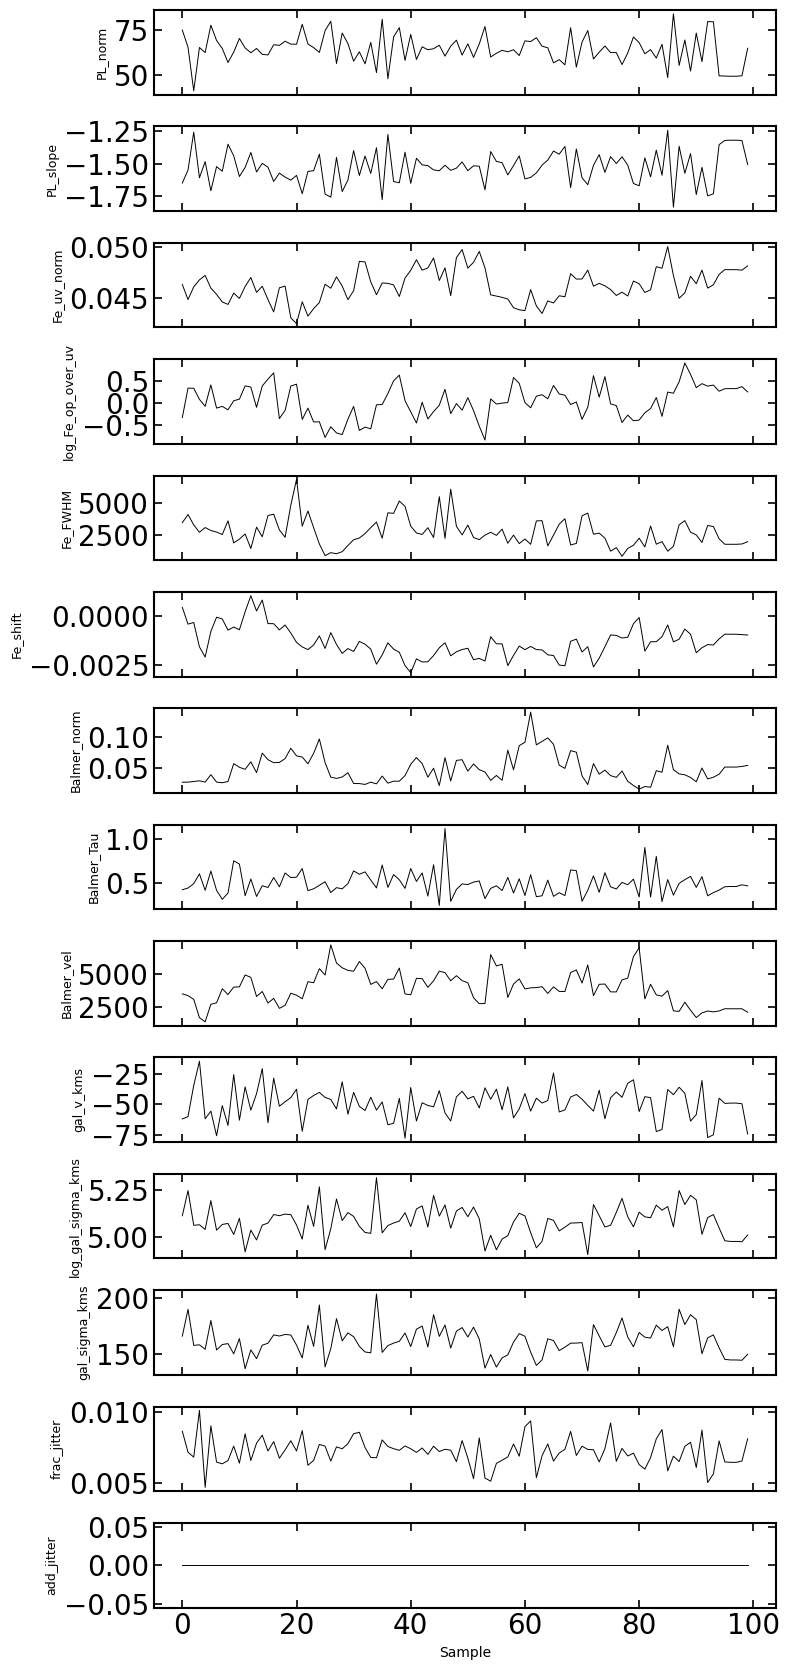

/Users/colinburke/research/jaxqsofit/src/jaxqsofit/core.py:5202: RuntimeWarning: Omitting parameters with non-finite values or no posterior variation from corner plot: add_jitter


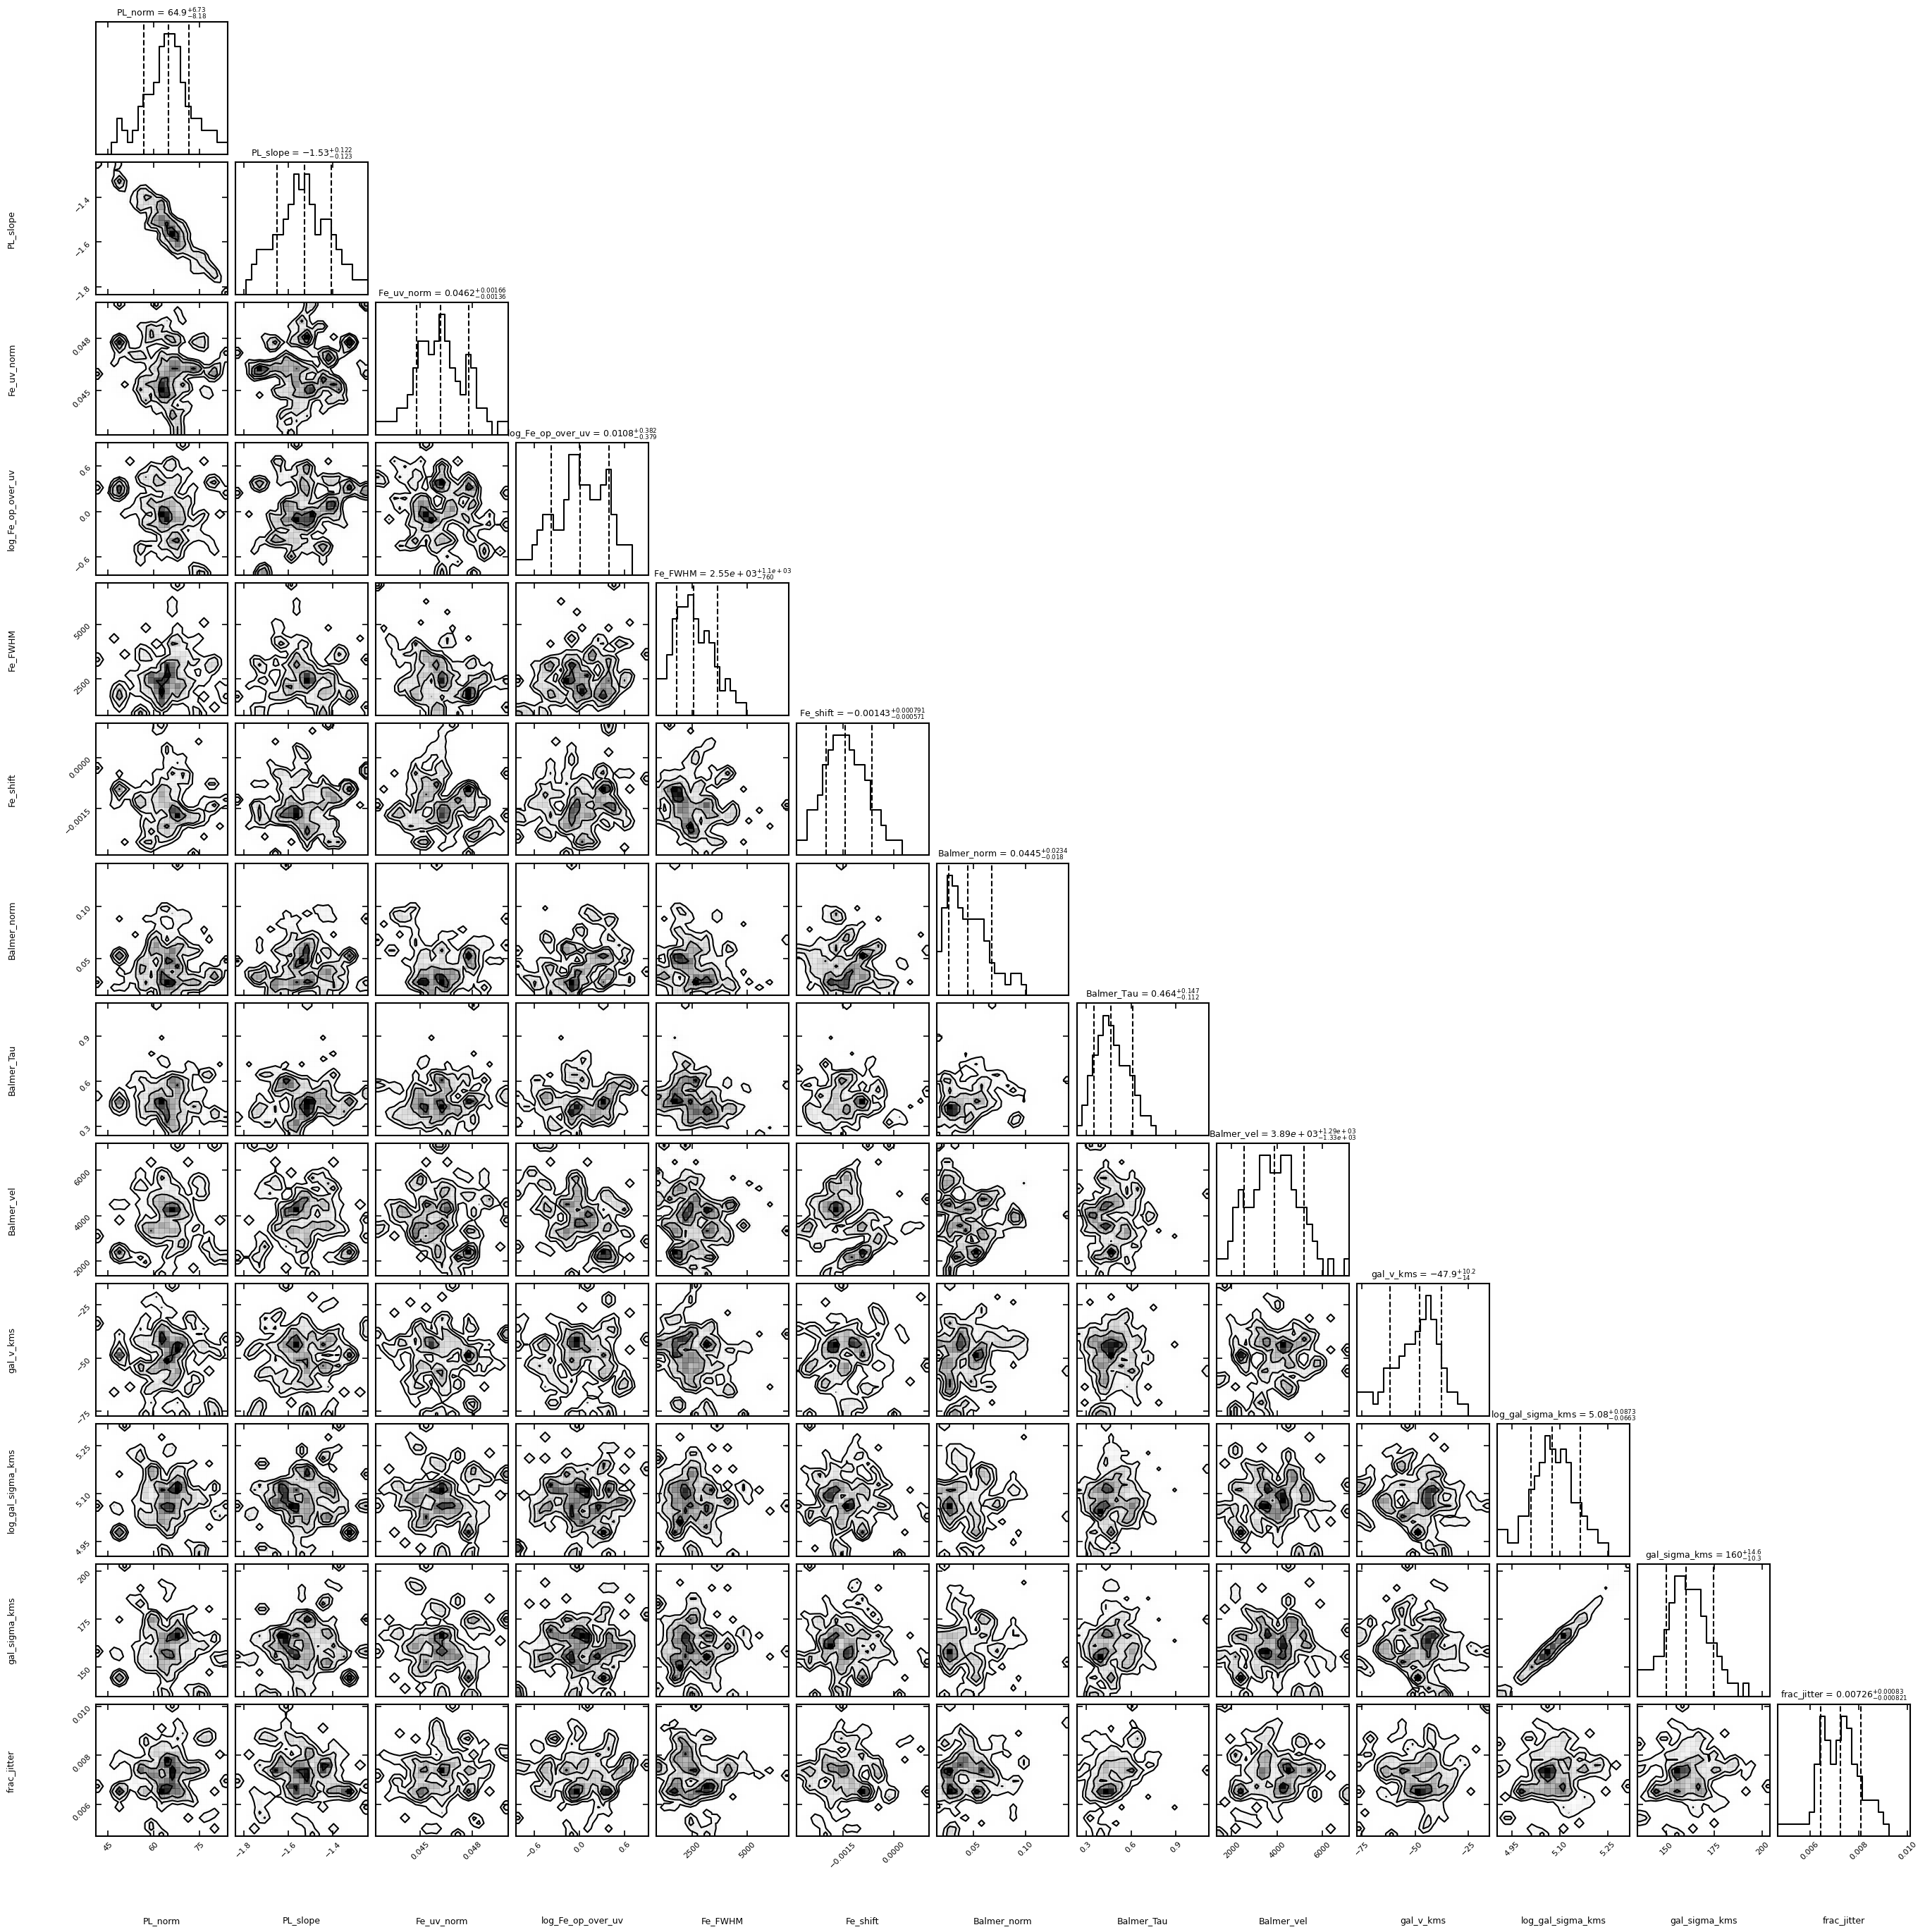

In [ ]:
q.plot_mcmc_diagnostics(
    #param_names='all',
    do_trace=True,
    do_corner=True,
    corner_bins=25,
    corner_max_points=1500,
    show_plot=True,
)


## 5. Measure broad-line FWHM and luminosity with posterior errors

`JAXQSOFit` provides:
- `line_profile_from_components(line_key)` for posterior-median component profiles
- `line_profile_from_draw(draw_index, line_key)` for one posterior draw
- `line_props(profile, wave=None)` -> `(fwhm_kms, integrated_area)`

The integrated area is in `10^-17 erg s^-1 cm^-2` units, so convert to luminosity with cosmology.


In [ ]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

def flux_to_luminosity(area_1e17, z):
    d_l_cm = cosmo.luminosity_distance(z).to(u.cm).value
    return area_1e17 * 1e-17 * 4.0 * np.pi * d_l_cm**2

amp_draws = np.asarray(q.pred_out['line_amp_per_component'])

for line_key in ["CIV_br", "MgII_br", "Hb_br", "Ha_br"]:
    fwhm_samp, logL_samp = [], []
    for i in range(amp_draws.shape[0]):
        prof = q.line_profile_from_draw(i, line_key)
        fwhm, area = q.line_props(prof)
        fwhm_samp.append(fwhm)
        if np.isfinite(area) and area > 0:
            logL_samp.append(np.log10(flux_to_luminosity(area, q.z)))
        else:
            logL_samp.append(np.nan)

    fwhm_samp = np.asarray(fwhm_samp, dtype=float)
    logL_samp = np.asarray(logL_samp, dtype=float)

    f16, f50, f84 = np.nanpercentile(fwhm_samp, [16, 50, 84])
    l16, l50, l84 = np.nanpercentile(logL_samp, [16, 50, 84])

    print(
        f"{line_key:8s}  "
        f"FWHM={f50:.1f} (+{f84-f50:.1f}/-{f50-f16:.1f}) km/s   "
        f"logL={l50:.3f} (+{l84-l50:.3f}/-{l50-l16:.3f})"
    )


CIV_br    FWHM=nan (+nan/-nan) km/s   logL=nan (+nan/-nan)
MgII_br   FWHM=nan (+nan/-nan) km/s   logL=nan (+nan/-nan)
Hb_br     FWHM=5936.7 (+482.5/-414.1) km/s   logL=41.417 (+0.040/-0.037)
Ha_br     FWHM=5454.0 (+206.6/-138.3) km/s   logL=42.074 (+0.016/-0.012)


/Users/colinburke/miniforge3/envs/jaxcpu/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1406: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


...but don't forget to subtract the instrumental resolution in quadrature before reporting the FWHM values.

## 6. Inspect posterior samples (recommended with `optax+nuts`)

If you used `config.inference.method = 'nuts'` or `'optax+nuts'`, posterior samples are stored in:
- `q.numpyro_samples`


In [ ]:
if hasattr(q, 'numpyro_samples') and q.numpyro_samples is not None:
    keys = sorted(q.numpyro_samples.keys())
    print('Num posterior params:', len(keys))
    print('First 20 keys:', keys)
else:
    print('No NumPyro samples available (likely config.inference.method=optax).')

Num posterior params: 89
First 20 keys: ['Balmer_Tau', 'Balmer_Tau_std', 'Balmer_norm', 'Balmer_norm_std', 'Balmer_vel', 'Fe_FWHM', 'Fe_FWHM_std', 'Fe_op_FWHM', 'Fe_op_shift', 'Fe_shift', 'Fe_shift_std', 'Fe_uv_FWHM', 'Fe_uv_norm', 'Fe_uv_norm_std', 'Fe_uv_shift', 'PL_apparent_log_norm_std', 'PL_apparent_slope_std', 'PL_norm', 'PL_slope', 'add_jitter', 'ebv', 'formed_stellar_mass', 'frac_fe_jitter', 'frac_jitter', 'frac_jitter_std', 'gal_lgmet', 'gal_lgmet_scatter', 'gal_sigma_kms', 'gal_v_kms', 'gal_v_kms_std', 'line_OIII_wing_log_fwhm', 'line_OIII_wing_log_fwhm_std', 'line_amp_Ha_std', 'line_amp_Hb_std', 'line_amp_Hd_std', 'line_amp_Hg_std', 'line_amp_OII_std', 'line_amp_group', 'line_broad_center_0_std', 'line_broad_center_1_std', 'line_broad_center_value_0', 'line_broad_center_value_1', 'line_broad_relative_offsets_0', 'line_broad_relative_offsets_0_std', 'line_broad_relative_offsets_1', 'line_broad_relative_offsets_1_std', 'line_dmu_group', 'line_dmu_independent_group', 'line_dmu_

## 7. Quick component diagnostics


In [ ]:
print('max data        :', np.nanmax(q.flux))
print('max total model :', np.nanmax(q.model_total))
print('max PL          :', np.nanmax(q.f_pl_model))
print('max host        :', np.nanmax(q.host))
print('max FeII        :', np.nanmax(q.f_fe_mgii_model + q.f_fe_balmer_model))
print('max Balmer cont :', np.nanmax(q.f_bc_model))
print('max lines       :', np.nanmax(q.f_line_model))


max data        : 159.85346122995483
max total model : 143.01907056160996
max PL          : 35.14302224434593
max host        : 30.118255907022398
max FeII        : 0.013393929310085158
max Balmer cont : 0.0038468063522291516
max lines       : 86.90667748869198
